# Рубежный контроль №1
## Группа: ИУ5-66Б
## Студент: Мохаммед Марьям
## Вариант 15
## Задача №2 – Обработка пропусков в данных
## Дополнительное требование: парные диаграммы (pairplot)

## 1. Импорт библиотек и загрузка данных

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

df = pd.read_csv('googleplaystore.csv')
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 2. Первичный анализ и пропуски

In [18]:
print(df.info())
print("\nПропуски:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB
None

Пропуски:
 App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1


## 3. Искусственные пропуски в Category

In [19]:
np.random.seed(42)
df_work = df.copy()
mask = np.random.random(len(df_work)) < 0.1
df_work.loc[mask, 'Category'] = np.nan
print("Пропуски в Category:", df_work['Category'].isnull().sum())
print("Пропуски в Rating:", df_work['Rating'].isnull().sum())

Пропуски в Category: 1109
Пропуски в Rating: 1474


## 4. Обработка пропусков
Category -> мода; Rating -> медиана

In [20]:
mode_cat = df_work['Category'].mode()[0]
df_work['Category'].fillna(mode_cat, inplace=True)

median_rating = df_work['Rating'].median()
df_work['Rating'].fillna(median_rating, inplace=True)

print("Пропуски после обработки:", df_work[['Category', 'Rating']].isnull().sum())

Пропуски после обработки: Category    1109
Rating      1474
dtype: int64


C:\Users\mokha\AppData\Local\Temp\ipykernel_10172\3353905568.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_work['Category'].fillna(mode_cat, inplace=True)
C:\Users\mokha\AppData\Local\Temp\ipykernel_10172\3353905568.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignme

## 5. Преобразование числовых признаков

In [21]:
def convert_size(s):
    if isinstance(s, str):
        s = s.strip()
        if s.endswith('M'):
            return float(s[:-1])
        elif s.endswith('k'):
            return float(s[:-1]) / 1024
    return np.nan

def convert_installs(s):
    if isinstance(s, str):
        s = s.replace(',', '').replace('+', '')
        try:
            return int(s)
        except:
            return np.nan
    return np.nan

def convert_price(s):
    if isinstance(s, str):
        s = s.replace('$', '')
        try:
            return float(s)
        except:
            return np.nan
    return np.nan

df_work['Size_MB'] = df_work['Size'].apply(convert_size)
df_work['Installs_num'] = df_work['Installs'].apply(convert_installs)
df_work['Price_num'] = df_work['Price'].apply(convert_price)

df_num = df_work[['Rating', 'Reviews', 'Size_MB', 'Installs_num', 'Price_num']].dropna()
print("Числовых строк:", df_num.shape)

Числовых строк: (7729, 5)


## 6. Парные диаграммы (pairplot)

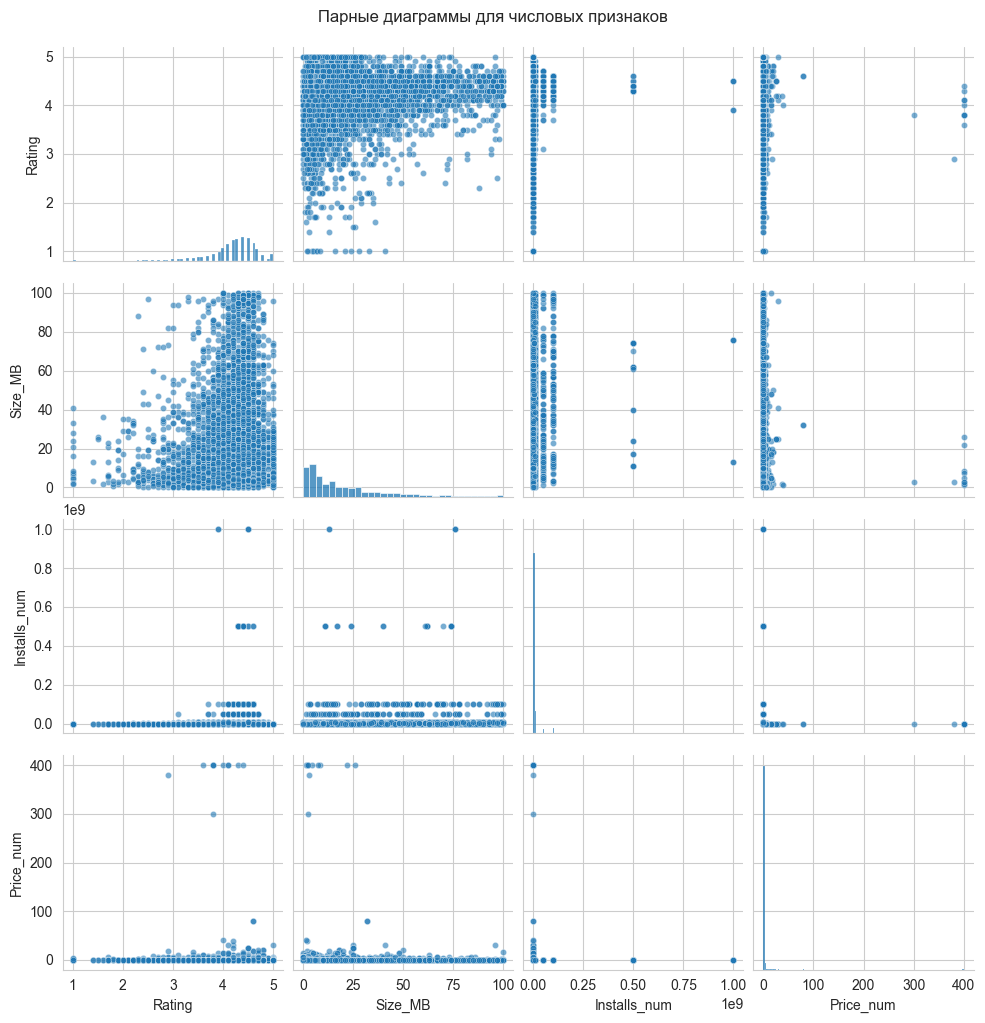

In [22]:
sample = df_num.sample(n=5000, random_state=42)
sns.pairplot(sample, diag_kind='hist', plot_kws={'alpha':0.6, 's':20})
plt.suptitle('Парные диаграммы для числовых признаков', y=1.02)
plt.show()

## 7. Выводы о выборе признаков для ML

**Рекомендуемые признаки:**
- Категориальные: Category, Type, Content Rating, Genres
- Количественные: Rating (если не целевая), Reviews, Size_MB, Installs_num, Price_num

**Обоснование:**
- Эти признаки несут информацию о популярности и успешности приложения.
- Категориальные признаки после кодирования (one-hot) позволят учесть нелинейные эффекты.
- Количественные признаки (Reviews и Installs) сильно коррелируют, что требует регуляризации для линейных моделей, но для деревьев не критично.

## 8. Заключение
Работа выполнена: загрузка данных, выявление пропусков, обработка (мода для Category, медиана для Rating), преобразование признаков, построение pairplot, рекомендации по выбору признаков.